In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import necessary modules
import os
import shutil

# Step 3: Create a folder in Drive to store CSVs
backup_folder = '/content/drive/My Drive/Colab_CSV_Backup'
os.makedirs(backup_folder, exist_ok=True)

# Step 4: Copy all CSV files from Colab session to Drive
for file in os.listdir():
    if file.endswith('.csv'):
        shutil.copy(file, backup_folder)
        print(f"Copied '{file}' to Drive.")

print("All CSV files have been safely backed up to Drive!")

Mounted at /content/drive
Copied 'risk_factors_cervical_cancer.csv' to Drive.
Copied 'traditional_classifiers_results.csv' to Drive.
All CSV files have been safely backed up to Drive!


In [ ]:
!pip install xgboost


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Classifiers
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import zipfile
import io
#unzip the uploaded file
with zipfile.ZipFile(io.BytesIO(uploaded['cervical+cancer+risk+factors.zip']),'r') as zip_ref:
  zip_ref.extractall()

In [ ]:
import os
os.listdir()

In [ ]:
import pandas as pd
#Load the dataset
data=pd.read_csv('risk_factors_cervical_cancer.csv')
#View first few rows
data.head()

In [ ]:
# Check how many missing values are in each column
data.isnull().sum()

In [ ]:
# Replace '?' with NaN
data = data.replace('?', pd.NA)

# Recheck missing values
data.isnull().sum()

In [ ]:
# Convert all columns to numeric, forcing errors to NaN
data = data.apply(pd.to_numeric, errors='coerce')

# Check types
data.dtypes

In [ ]:
# Fill missing values with column mean
data = data.fillna(data.mean(numeric_only=True))

In [ ]:
# Check again if any null values remain
data.isnull().sum().sum()  # Should be 0

# View cleaned data
data.head()

In [ ]:
# Set 'Biopsy' as target label
target_column = 'Biopsy'

In [ ]:
# X = all columns except target
X = data.drop(columns=[target_column])

# y = target column
y = data[target_column]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cervical+cancer+risk+factors.zip to cervical+cancer+risk+factors.zip


In [ ]:
import zipfile
import io
#unzip the uploaded file
with zipfile.ZipFile(io.BytesIO(uploaded['cervical+cancer+risk+factors.zip']),'r') as zip_ref:
  zip_ref.extractall()

In [ ]:
import os
os.listdir()

['.config',
 'cervical+cancer+risk+factors.zip',
 'drive',
 'risk_factors_cervical_cancer.csv',
 'sample_data']

In [ ]:
import pandas as pd
df = pd.read_csv("risk_factors_cervical_cancer.csv")

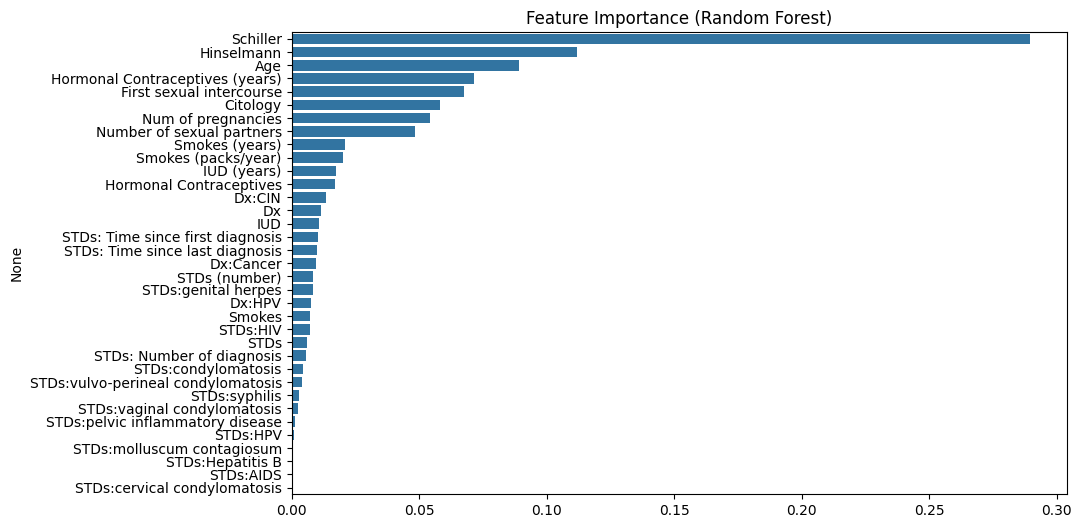

Selected Features: ['Hormonal Contraceptives (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:genital herpes', 'STDs:HIV', 'STDs: Number of diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology']
Shape of dataset after feature selection: (858, 15)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [14 21] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
# Step 5: Feature Selection
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

# If you just uploaded the dataset again
df = pd.read_csv("risk_factors_cervical_cancer.csv")

# Replace '?' with NaN
df = df.replace('?', pd.NA)

# Convert all columns to numeric, forcing errors to NaN
df = df.apply(pd.to_numeric, errors='coerce')

# Make sure to fill missing values if not done already
df = df.fillna(df.mean(numeric_only=True))

# Define X and y
X = df.drop(columns=['Biopsy'])  # Replace 'Biopsy' with your target column name if different
y = df['Biopsy']

# ---- Feature importance using Random Forest ----
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.title("Feature Importance (Random Forest)")
plt.show()

# ---- Univariate feature selection (Top K best) ----
selector = SelectKBest(score_func=f_classif, k=15)  # choose top 15 features
X_selected = selector.fit_transform(X, y)

selected_features = feature_names[selector.get_support()]
print("Selected Features:", selected_features.tolist())

# Create new dataframe with only selected features
df_selected = df[selected_features.tolist() + ['Biopsy']]

print("Shape of dataset after feature selection:", X_selected.shape)

In [ ]:
# Step 6: Train and Evaluate Traditional Classifiers

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import classifiers
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import tree  # For J48 equivalent

# Use the selected features dataframe from Step 5
df = df_selected.copy()

# Define X and y
X = df.drop(columns=['Biopsy'])
y = df['Biopsy']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize classifiers
classifiers = {
    "SVM": SVC(kernel='linear', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=1000, random_state=42),
    "J48 (CART equivalent)": DecisionTreeClassifier(criterion='entropy', random_state=42)
}

# Dictionary to store results
results = []

# Train & evaluate each classifier
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# Optional: Save results to CSV
results_df.to_csv("traditional_classifiers_results.csv", index=False)

                   Model  Accuracy  Precision  Recall  F1-Score
0                    SVM    0.9651     0.6923  0.8182    0.7500
1          Decision Tree    0.9360     0.5000  0.3636    0.4211
2            Naive Bayes    0.8953     0.3600  0.8182    0.5000
3                    KNN    0.9419     0.5714  0.3636    0.4444
4    Logistic Regression    0.9535     0.6667  0.5455    0.6000
5          Random Forest    0.9477     0.6000  0.5455    0.5714
6                    MLP    0.9419     0.5556  0.4545    0.5000
7  J48 (CART equivalent)    0.9360     0.5000  0.3636    0.4211


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Path to your CSV after Step 6
csv_path = "/content/drive/MyDrive/Colab_CSV_Backup/traditional_classifiers_results.csv"

# Load dataset
df_selected = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print(df_selected.head())

Dataset loaded successfully!
                 Model  Accuracy  Precision  Recall  F1-Score
0                  SVM    0.9651     0.6923  0.8182    0.7500
1        Decision Tree    0.9360     0.5000  0.3636    0.4211
2          Naive Bayes    0.8953     0.3600  0.8182    0.5000
3                  KNN    0.9419     0.5714  0.3636    0.4444
4  Logistic Regression    0.9535     0.6667  0.5455    0.6000


In [ ]:
# Step 6: Train and Evaluate Traditional Classifiers

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import classifiers
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import tree  # For J48 equivalent

# Use the selected features dataframe from Step 5
df = df_selected.copy()

# Define X and y
X = df.drop(columns=['Biopsy'])
y = df['Biopsy']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize classifiers
classifiers = {
    "SVM": SVC(kernel='linear', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=1000, random_state=42),
    "J48 (CART equivalent)": DecisionTreeClassifier(criterion='entropy', random_state=42)
}

# Dictionary to store results
results = []

# Train & evaluate each classifier
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# Optional: Save results to CSV
results_df.to_csv("traditional_classifiers_results.csv", index=False)

                   Model  Accuracy  Precision  Recall  F1-Score
0                    SVM    0.9651     0.6923  0.8182    0.7500
1          Decision Tree    0.9360     0.5000  0.3636    0.4211
2            Naive Bayes    0.8953     0.3600  0.8182    0.5000
3                    KNN    0.9419     0.5714  0.3636    0.4444
4    Logistic Regression    0.9535     0.6667  0.5455    0.6000
5          Random Forest    0.9477     0.6000  0.5455    0.5714
6                    MLP    0.9419     0.5556  0.4545    0.5000
7  J48 (CART equivalent)    0.9360     0.5000  0.3636    0.4211


XGBoost Model Performance:
Accuracy: 0.9535
Precision: 0.7143
Recall: 0.4545
F1-score: 0.5556
ROC-AUC: 0.9111


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [06:47:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 1000x600 with 0 Axes>

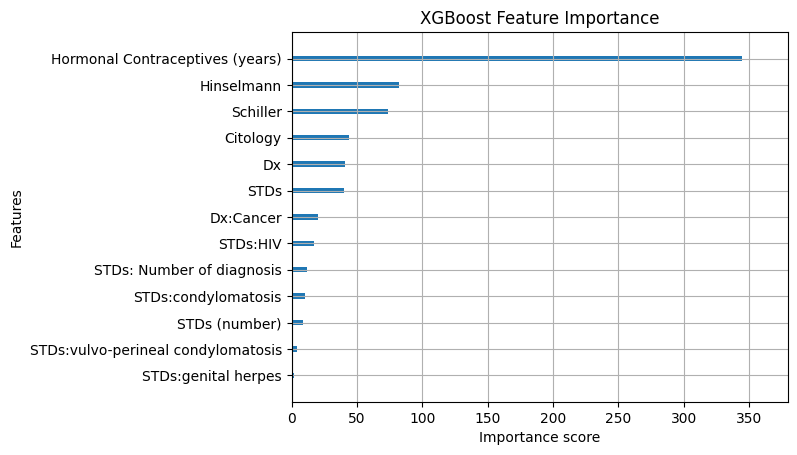

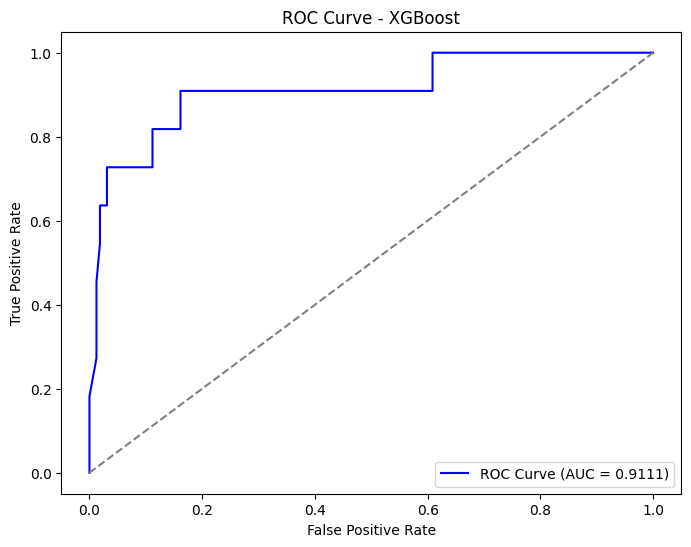

In [ ]:
# Step 7: XGBoost Integration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import xgboost as xgb

# Assuming df_selected is already loaded
# Split into X and y
X = df_selected.drop(columns=['Biopsy'])
y = df_selected['Biopsy']

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize XGBoost Classifier
xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Train the model
xgb_clf.fit(X_train, y_train)

# Predictions
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:, 1]

# ---- Evaluation Metrics ----
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("XGBoost Model Performance:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# ---- Plot Feature Importance ----
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_clf, importance_type='weight', show_values=False)
plt.title("XGBoost Feature Importance")
plt.show()

# ---- Plot ROC Curve ----
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [06:49:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Accuracies: {'SVM': 0.9418604651162791, 'DT': 0.936046511627907, 'NB': 0.8953488372093024, 'KNN': 0.9418604651162791, 'LR': 0.9534883720930233, 'J48': 0.936046511627907, 'MLP': 0.9418604651162791, 'RF': 0.9476744186046512, 'XGB': 0.9534883720930233}
Assigned Weights: {'SVM': 0.11149346180316584, 'DT': 0.1108052305574673, 'NB': 0.10598761183757742, 'KNN': 0.11149346180316584, 'LR': 0.11286992429456295, 'J48': 0.1108052305574673, 'MLP': 0.11149346180316584, 'RF': 0.1121816930488644, 'XGB': 0.11286992429456295}


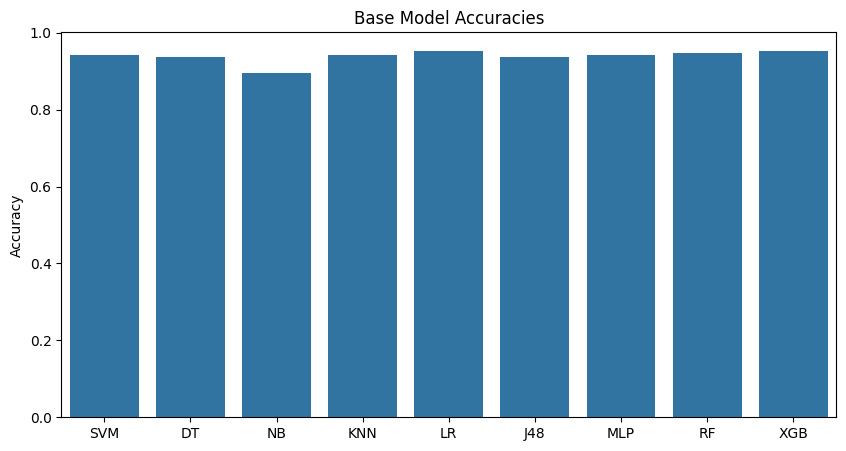

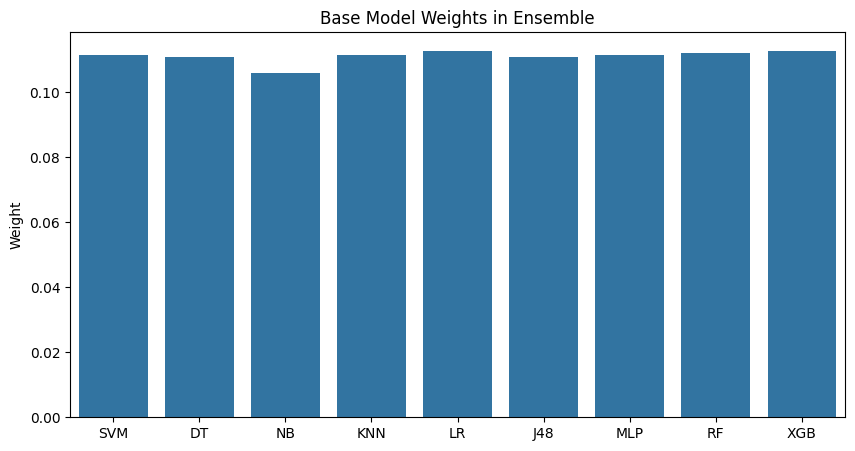

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [06:49:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Weighted Voting Ensemble Performance:
Accuracy: 0.9419
Precision: 0.5556
Recall: 0.4545
F1-score: 0.5000
ROC-AUC: 0.9441


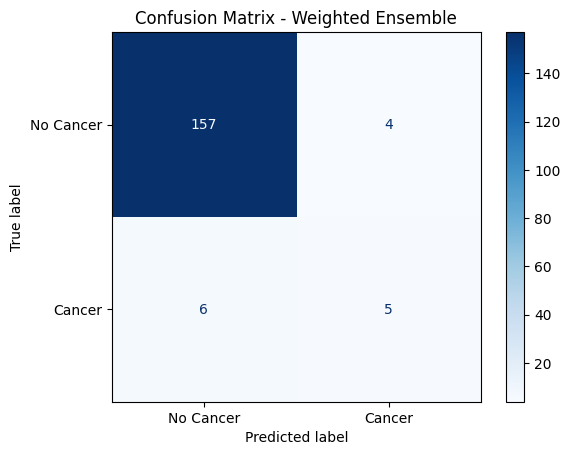

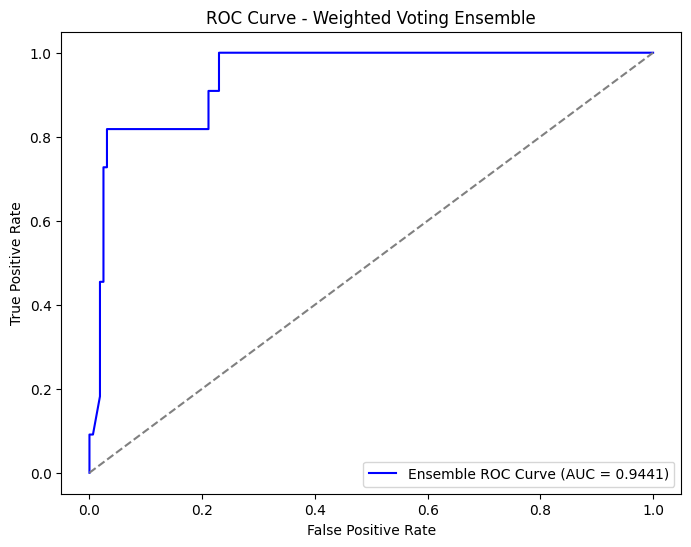

In [ ]:
# Step 8: Weighted Voting Ensemble

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define base classifiers
models = [
    ('SVM', SVC(probability=True, random_state=42)),
    ('DT', DecisionTreeClassifier(random_state=42)),
    ('NB', GaussianNB()),
    ('KNN', KNeighborsClassifier()),
    ('LR', LogisticRegression(max_iter=1000, random_state=42)),
    ('J48', DecisionTreeClassifier(random_state=42)),  # J48 equivalent in scikit-learn
    ('MLP', MLPClassifier(max_iter=1000, random_state=42)),
    ('RF', RandomForestClassifier(random_state=42)),
    ('XGB', xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False))
]

# Train each model and store accuracy for weighting
weights = []
model_names = []
accuracies = []

for name, model in models:
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    model_names.append(name)
    accuracies.append(acc)
    weights.append(acc)  # using accuracy directly as weight

# Normalize weights (optional)
total = sum(weights)
weights = [w / total for w in weights]

print("Model Accuracies:", dict(zip(model_names, accuracies)))
print("Assigned Weights:", dict(zip(model_names, weights)))

# Plot Model Accuracy vs Weight
plt.figure(figsize=(10, 5))
sns.barplot(x=model_names, y=accuracies)
plt.title("Base Model Accuracies")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x=model_names, y=weights)
plt.title("Base Model Weights in Ensemble")
plt.ylabel("Weight")
plt.show()

# Weighted Voting Classifier
ensemble = VotingClassifier(estimators=models, voting='soft', weights=weights)
ensemble.fit(X_train, y_train)

# Predictions
y_pred_ensemble = ensemble.predict(X_test)
y_pred_proba_ensemble = ensemble.predict_proba(X_test)[:, 1]

# Evaluation Metrics
acc_ens = accuracy_score(y_test, y_pred_ensemble)
prec_ens = precision_score(y_test, y_pred_ensemble)
rec_ens = recall_score(y_test, y_pred_ensemble)
f1_ens = f1_score(y_test, y_pred_ensemble)
roc_auc_ens = roc_auc_score(y_test, y_pred_proba_ensemble)

print("\nWeighted Voting Ensemble Performance:")
print(f"Accuracy: {acc_ens:.4f}")
print(f"Precision: {prec_ens:.4f}")
print(f"Recall: {rec_ens:.4f}")
print(f"F1-score: {f1_ens:.4f}")
print(f"ROC-AUC: {roc_auc_ens:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancer', 'Cancer'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Weighted Ensemble")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_ensemble)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Ensemble ROC Curve (AUC = {roc_auc_ens:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Weighted Voting Ensemble')
plt.legend(loc='lower right')
plt.show()

Final Model Comparison Table:
               Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0                SVM  0.941860   0.555556  0.454545  0.500000  0.953698
1                 DT  0.936047   0.500000  0.363636  0.421053  0.743648
2                 NB  0.895349   0.360000  0.818182  0.500000  0.862225
3                KNN  0.941860   0.571429  0.363636  0.444444  0.869848
4                 LR  0.953488   0.666667  0.545455  0.600000  0.898927
5                J48  0.936047   0.500000  0.363636  0.421053  0.743648
6                MLP  0.941860   0.555556  0.454545  0.500000  0.893281
7                 RF  0.947674   0.600000  0.545455  0.571429  0.969226
8                XGB  0.953488   0.714286  0.454545  0.555556  0.911067
9  Weighted Ensemble  0.941860   0.555556  0.454545  0.500000  0.944099


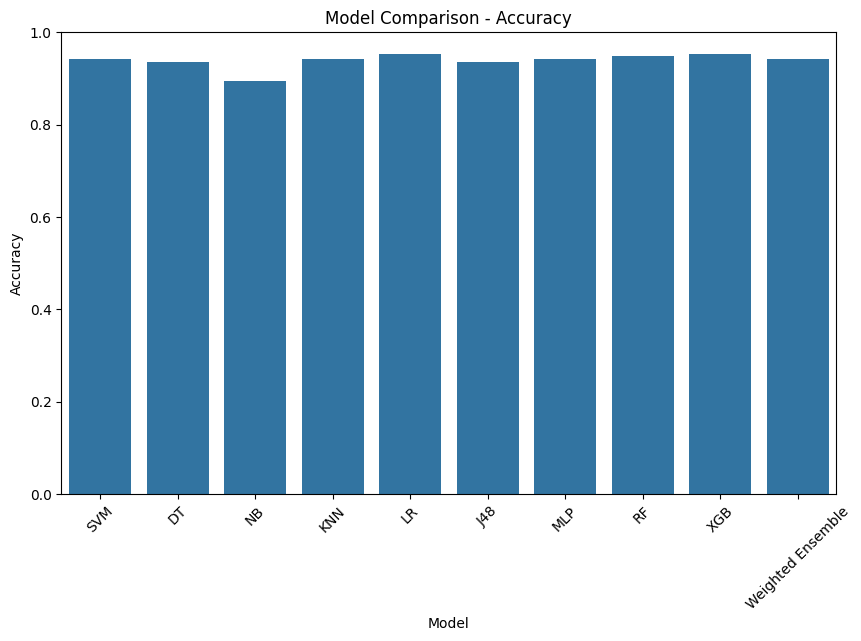

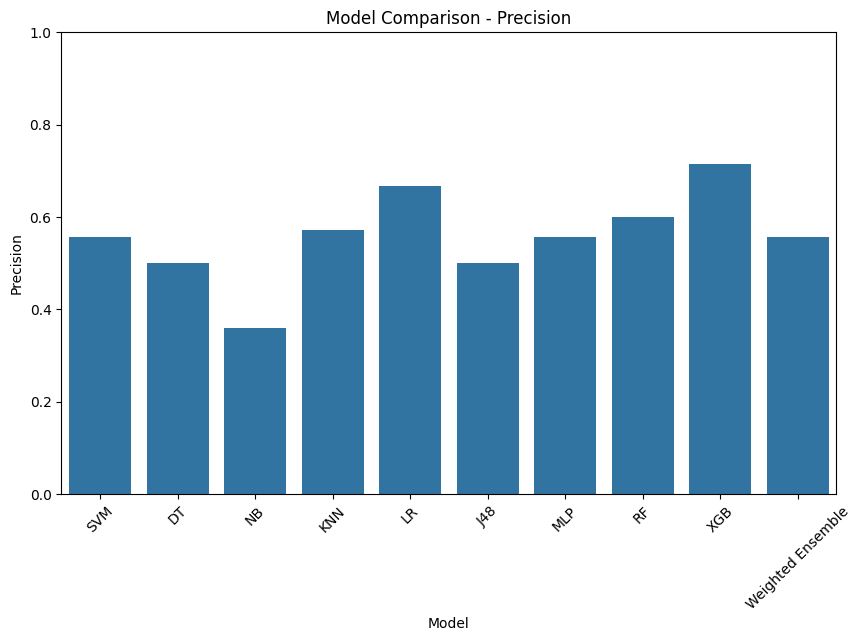

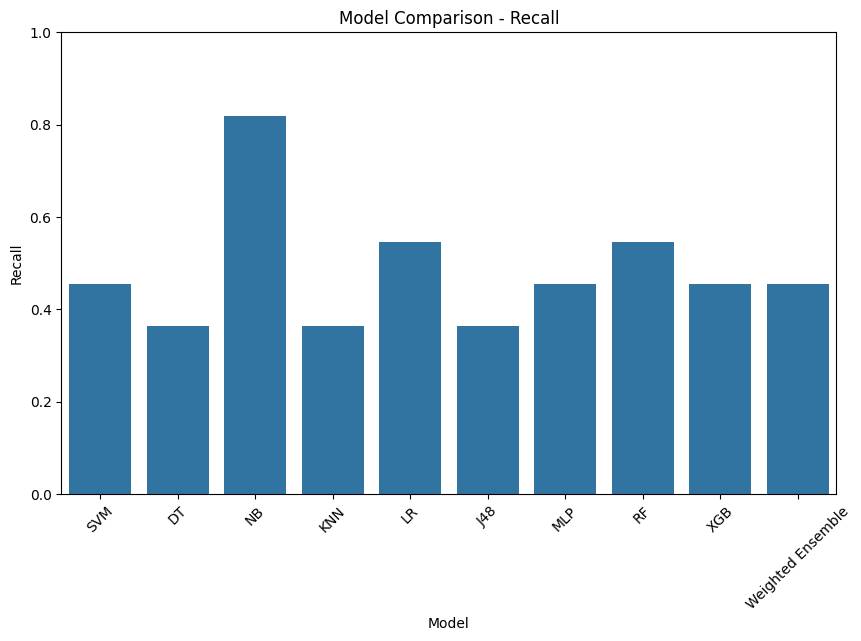

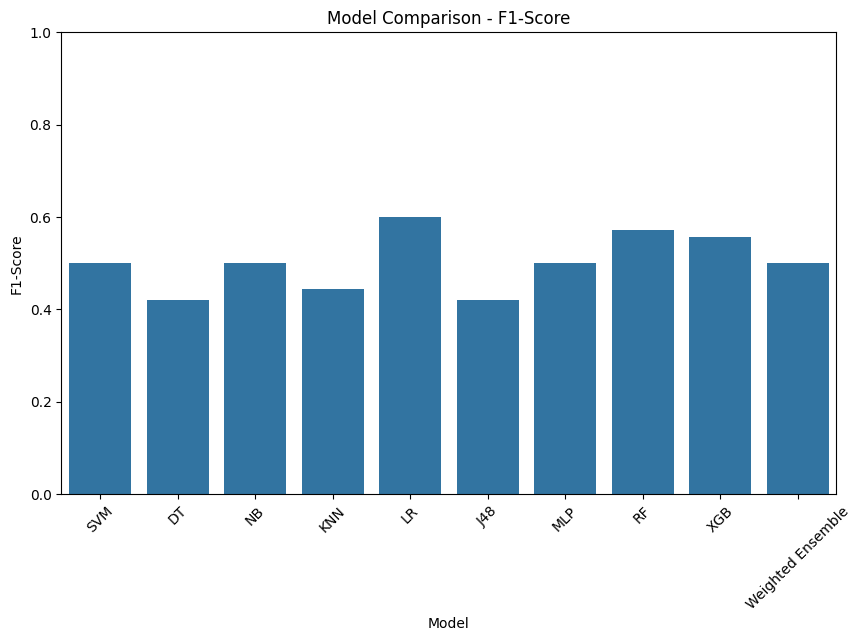

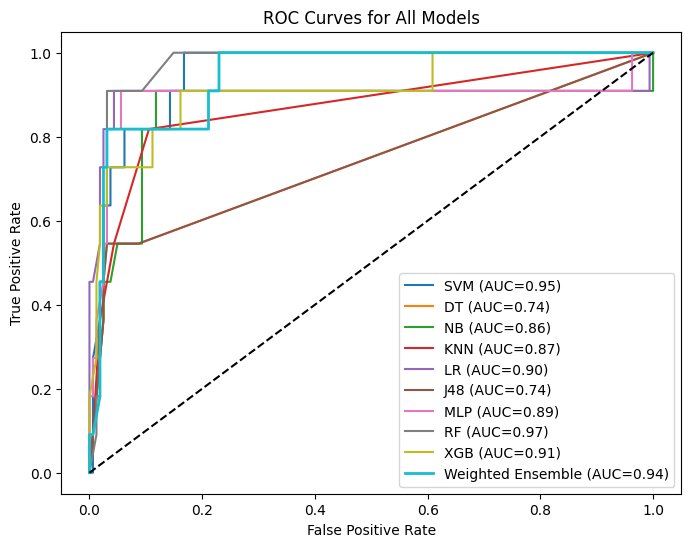

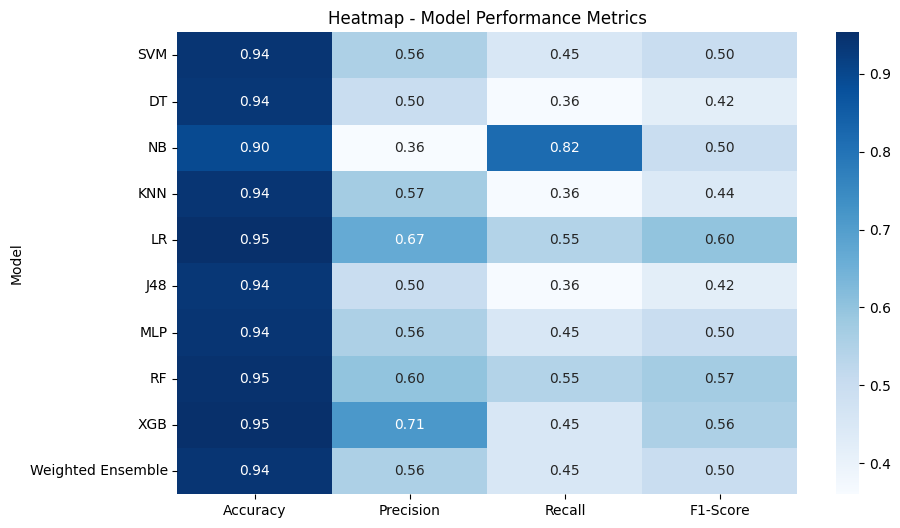

In [ ]:
# Step 9: Final Evaluation & Model Comparison

# Collect metrics for all models including ensemble
final_results = []

for name, model in models:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    final_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

# Ensemble evaluation
y_pred_ens = ensemble.predict(X_test)
y_proba_ens = ensemble.predict_proba(X_test)[:, 1]
final_results.append({
    'Model': 'Weighted Ensemble',
    'Accuracy': accuracy_score(y_test, y_pred_ens),
    'Precision': precision_score(y_test, y_pred_ens),
    'Recall': recall_score(y_test, y_pred_ens),
    'F1-Score': f1_score(y_test, y_pred_ens),
    'ROC-AUC': roc_auc_score(y_test, y_proba_ens)
})

# Convert to DataFrame
results_df = pd.DataFrame(final_results)

print("Final Model Comparison Table:")
print(results_df)

# --- Diagram 1: Accuracy, Precision, Recall, F1-score comparison ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Model', y=metric, data=results_df)
    plt.title(f'Model Comparison - {metric}')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.show()

# --- Diagram 2: ROC Curves for all models ---
plt.figure(figsize=(8, 6))

for name, model in models:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# Ensemble ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_ens)
roc_auc = roc_auc_score(y_test, y_proba_ens)
plt.plot(fpr, tpr, label=f"Weighted Ensemble (AUC={roc_auc:.2f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.show()

# --- Diagram 3: Heatmap of Model Metrics ---
plt.figure(figsize=(10, 6))
sns.heatmap(results_df.set_index('Model')[metrics], annot=True, cmap='Blues', fmt=".2f")
plt.title("Heatmap - Model Performance Metrics")
plt.show()